<a href="https://colab.research.google.com/github/TakumiFujiwara-CS/NoEmptySeatsWebsite/blob/main/2026_IntroductionToLLMs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Setup: GPU Environment

The LLM you will use in this notebook needs to run on a GPU. To run code in an environment with a GPU on Colab, you must specifically connect to one. In the toolbar, find the runtime menu, select "change runtime type", and set the runtime to be a T4 GPU. Colab offers higher tier GPUs (A100s) for premium users. Students are able to sign up for a year of premium, but higher tier GPUs are not needed for this assignment.

In [6]:
import torch
import matplotlib.pyplot as plt
import torch.nn.functional as F
from transformers import AutoModelForCausalLM, AutoTokenizer, pipeline

## Loading a model
For this assignment, you will use Microsoft's open source model [Phi 4 mini](https://techcommunity.microsoft.com/blog/azure-ai-foundry-blog/introducing-phi-4-microsoft%E2%80%99s-newest-small-language-model-specializing-in-comple/4357090). The Phi models from Microsoft strike a good balance between speed of execution and quality of text generation. You will be running the model directly on a Google Colab T4 GPU.

The first step in this homework is downloading the model from [Hugging Face](https://huggingface.co/models) to run locally. Hugging Face hosts many open weight models and allows easy access to them. If you want to, you can try other models as well and compare their performance and speed, just change the name of the model below to another entry from the Hugging Face model page.

In [7]:
# Which model to use
model_name = "microsoft/Phi-4-mini-instruct"

In [8]:
print("Loading model... (this may take a minute)")
# Load Phi-4 small model onto GPU (cuda)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    device_map="cuda",
    torch_dtype="auto",
    trust_remote_code=False,
)
# Load tokenizer (more on that soon)
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Create a pipeline for easy text generation
generator = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
    return_full_text=False,
    max_new_tokens=500,
    do_sample=False
)
print("Model loaded successfully!")

Loading model... (this may take a minute)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

This model config has set a `rope_parameters['original_max_position_embeddings']` field, to be used together with `max_position_embeddings` to determine a scaling factor. Please set the `factor` field of `rope_parameters`with this ratio instead -- we recommend the use of this field over `original_max_position_embeddings`, as it is compatible with most model architectures.


model.safetensors.index.json: 0.00B [00:00, ?B/s]

...

tokenizer.json:   0%|          | 0.00/15.5M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/249 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/587 [00:00<?, ?B/s]

The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Passing `generation_config` together with generation-related arguments=({'max_new_tokens', 'do_sample'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


Model loaded successfully!


## Tokenization

Language models have a **fixed vocabulary** of tokens that they can recognize and generate. The size of this vocabulary differs from language model to language model. Phi-4 uses a vocabulary size of **200,064 tokens**. Each token may correspond to:
- A complete word (like "the", "capital")
- Parts of a word (like "Rhode" and "Island" might be separate tokens)
- Punctuation marks
- Special characters or symbols

To pass a prompt into our language model, we must first divide the prompt into tokens. We can identify each token by a unique ID between 0 and the max vocabulary size (200,063 for Phi-4). This process is called **tokenization**.

**Why do we need tokenization?**
- Language models work with numbers, not raw text
- A fixed vocabulary allows the model to handle any input text consistently
- Even if the model encounters a word it has never seen before, it can break it down into smaller, recognizable pieces

The following code block shows how the prompt "What is the capital of Rhode Island?" is tokenized.

In [9]:
prompt = "What is the capital of Rhode Island?"
tokens = tokenizer(prompt, return_tensors="pt").to("cuda")

print("Tokenizing an input prompt:")
print(f"Input text: {prompt}")
print(f"Token IDs: {tokens['input_ids']}")

print("Now let's decode those token ids back to tokens:")
print(f"Decoded tokens: {tokenizer.convert_ids_to_tokens(tokens['input_ids'][0])}")
print(f"Number of tokens: {len(tokens['input_ids'][0])}")

Tokenizing an input prompt:
Input text: What is the capital of Rhode Island?
Token IDs: tensor([[ 4827,   382,   290,  9029,   328, 89356, 14226,    30]],
       device='cuda:0')
Now let's decode those token ids back to tokens:
Decoded tokens: ['What', 'Ġis', 'Ġthe', 'Ġcapital', 'Ġof', 'ĠRhode', 'ĠIsland', '?']
Number of tokens: 8


What's up with those Ġ's? Those are a special symbol used by this tokenizer to denote a leading space. So the token "Ġis" is not just the word "is", but specifically "_is".

In [10]:
# We can use the decoder to directly decode a list of tokens all at once without additional symbols
print(tokenizer.decode(tokens['input_ids'][0]))

What is the capital of Rhode Island?


What happens when a language model encounters words that is has never seen before? What if you make a spelling mistake? The tokenizer ensures that even if an LLM has not seen a word before, it can at least reason about the individual tokens that make up that word.

In [11]:
examples = [
    "Hello world",
    "Hello wrold", # (spelling mistake on purpose)
    "Hello, world!",
    "HelloWorld",
    "12345",
    "   spaces   ",
]

for ex in examples:
    tok = tokenizer(ex, return_tensors="pt")
    token_strings = tokenizer.convert_ids_to_tokens(tok['input_ids'][0])
    print(f"  '{ex}' -> {len(tok['input_ids'][0])} tokens: {token_strings}")

  'Hello world' -> 2 tokens: ['Hello', 'Ġworld']
  'Hello wrold' -> 4 tokens: ['Hello', 'Ġw', 'ro', 'ld']
  'Hello, world!' -> 4 tokens: ['Hello', ',', 'Ġworld', '!']
  'HelloWorld' -> 2 tokens: ['Hello', 'World']
  '12345' -> 2 tokens: ['123', '45']
  '   spaces   ' -> 3 tokens: ['ĠĠ', 'Ġspaces', 'ĠĠĠ']


Look at how "HelloWorld" vs "Hello world" are tokenized differently. What does this tell you about how the model "sees" text? Why might this matter for how the model understands language?

##Task:
Language models use a fixed vocabulary size. Even when that vocabulary size is quite large (e.g., 200,000 tokens), a language model is likely to see words it has never seen before (especially when we consider how many typos we make).

How does the tokenizer handle this?

Task: tokenize the word "gobbledygook"

In [12]:
output_tokens = tokenizer.convert_ids_to_tokens(
    tokenizer("gobbledygook", return_tensors="pt")["input_ids"][0]
)

print(output_tokens)

None


## Running the LLM (Forward Pass)

To run the LLM, you simply need to pass in the tokens provided by the tokenizer. We can run the model once to get predictions of the most likely token to follow our input prompt.

**What happens during a forward pass?**
- The model processes all input tokens simultaneously
- For each position in the sequence, it predicts what token should come next
- The output is a 3D tensor (a matrix with more than 2 dimensions) containing scores (called **logits**) for every possible next token

**Understanding the output shape:**
- **Batch dimension**: How many examples we're processing at once (1 in our case)
- **Sequence dimension**: How many tokens are in our input (8 for our example)
- **Vocabulary dimension**: Scores for all possible next tokens (200,064 total)

In [13]:
prompt = "What is the capital of Rhode Island?"
tokens = tokenizer(prompt, return_tensors="pt").to("cuda")

# torch.no_grad turns off the compute graph (because we don't need gradients here)
# This makes everything faster and more memory efficient
with torch.no_grad():
    # The ** operator is a dictionary unpacking operator
    logits = model(**tokens).logits.float()

print(f"Output shape: {logits.shape}")
print(f"Batch size: {logits.shape[0]}")
print(f"Sequence length: {logits.shape[1]}")
print(f"Vocabulary size: {logits.shape[2]}")

Output shape: torch.Size([1, 8, 200064])
Batch size: 1
Sequence length: 8
Vocabulary size: 200064


The language model should output something that is $1\times 8 \times 200064$. The first dimension is the batch dimension. If we wanted to run multiple examples through the LLM at once (i.e., run the model for a batch of examples) it would return separate outputs for each example in that batch. The third dimension is the size of the vocabulary. The language model is outputting a score for each token in its vocabulary based on what should come next. These scores are referred to as "logits". During training, these logits are passed into a softmax function to produce probability predictions rather than raw scores.

But what is that second dimension and why is it of size 8? Language models don't just predict one token - they predict what should follow **every** position in the input sequence.

This might seem strange at first. Why would we want to know what comes after "What" or "is" when we already know the full sentence? This ends up being important for:
- **Training efficiency**: During training, we can learn from every position in every sentence
- **Parallel processing**: All predictions can be computed simultaneously
- **Understanding context**: The model learns how context affects predictions at each position

Let's look at each of these 8 outputs! For now, we will just use the token with the highest score (the argmax of the scores output by the LLM).

In [14]:
for i in range(logits.shape[1]):
  highest_scoring_token = logits[0, i, :].argmax()
  print(f"Token {i}: {tokenizer.decode(highest_scoring_token)}")

Token 0:  is
Token 1:  the
Token 2:  value
Token 3:  of
Token 4:  France
Token 5:  Island
Token 6: ?
Token 7:  The


Notice how the model's predictions change as it sees more context. The model doesn't just produce a single token prediction every time it is run. It produces a prediction of what comes next for every token position, and these predictions get more accurate and specific as more context becomes available.

For example:
- After seeing just "What", the model might predict common continuations like "is", "are", "do"
- After seeing "What is", it might predict "the", "a", "your"
- After seeing "What is the", it becomes much more specific about likely continuations

In [15]:
for i in range(logits.shape[1]):
  highest_scoring_token = logits[0, i, :].argmax()
  print(f"Context: '{tokenizer.decode(tokens['input_ids'][0][:i+1])}'")
  print(f"Continuation: '{tokenizer.decode(highest_scoring_token)}'")

Context: 'What'
Continuation: ' is'
Context: 'What is'
Continuation: ' the'
Context: 'What is the'
Continuation: ' value'
Context: 'What is the capital'
Continuation: ' of'
Context: 'What is the capital of'
Continuation: ' France'
Context: 'What is the capital of Rhode'
Continuation: ' Island'
Context: 'What is the capital of Rhode Island'
Continuation: '?'
Context: 'What is the capital of Rhode Island?'
Continuation: ' The'


## Interpreting the Outputs of the LLM

1. ' The'      (logit: 34.50)
2. ' Rhode'    (logit: 34.00)
3. ' What'     (logit: 33.00)
4. ' A'        (logit: 32.75)
5. ' ('        (logit: 32.50)
6. ' \n'       (logit: 32.50)
7. ' I'        (logit: 32.25)
8. ' Can'      (logit: 32.25)
9. ' To'       (logit: 31.88)
10. ' Your'     (logit: 31.75)
Logit of nonsense followup: Virginia
logit: 20.88


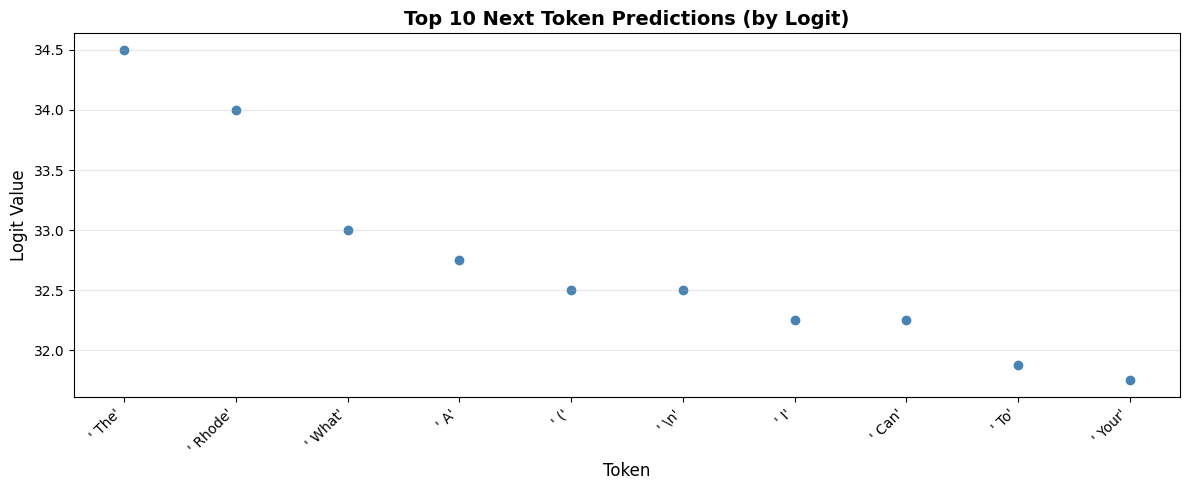

In [16]:
# For the final token in the output (i.e., prediction on what should come after our prompt)
last_token_logits = logits[0, -1, :]

# Sort the logits of all tokens and grab the top 10 tokens
top_10_values, top_10_indices = last_token_logits.sort(descending=True)
top_10_indices = top_10_indices[:10]
top_10_values = top_10_values[:10]

decoded_tokens = [repr(tokenizer.decode(idx)) for idx in top_10_indices]
for i, (token, logit) in enumerate(zip(decoded_tokens, top_10_values)):
    print(f"{i+1}. {token:11s} (logit: {logit:.2f})")

# Let's check the score of a non-sequitor
print("Logit of nonsense followup: Virginia")
print(f"logit: {last_token_logits[tokenizer.encode('Virginia')].item():.2f}")

# Visualize top predictions
plt.figure(figsize=(12, 5))
plt.scatter(range(len(decoded_tokens)), top_10_values.cpu().numpy(), color='steelblue')
plt.xticks(range(len(decoded_tokens)), decoded_tokens, rotation=45, ha='right')
plt.xlabel('Token', fontsize=12)
plt.ylabel('Logit Value', fontsize=12)
plt.title('Top 10 Next Token Predictions (by Logit)', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

The logits are converted to probabilities using a softmax function

Sum of probabilities for top-10 scoring tokens: 0.608244
Sum of all probabilities: 1.000000
1. ' The'               logit:   34.50  ->  prob: 0.23204 (23.20%)
2. ' Rhode'             logit:   34.00  ->  prob: 0.14074 (14.07%)
3. ' What'              logit:   33.00  ->  prob: 0.05178 ( 5.18%)
4. ' A'                 logit:   32.75  ->  prob: 0.04032 ( 4.03%)
5. ' ('                 logit:   32.50  ->  prob: 0.03140 ( 3.14%)
6. ' \n'                logit:   32.50  ->  prob: 0.03140 ( 3.14%)
7. ' I'                 logit:   32.25  ->  prob: 0.02446 ( 2.45%)
8. ' Can'               logit:   32.25  ->  prob: 0.02446 ( 2.45%)
9. ' To'                logit:   31.88  ->  prob: 0.01681 ( 1.68%)
10. ' Your'              logit:   31.75  ->  prob: 0.01483 ( 1.48%)


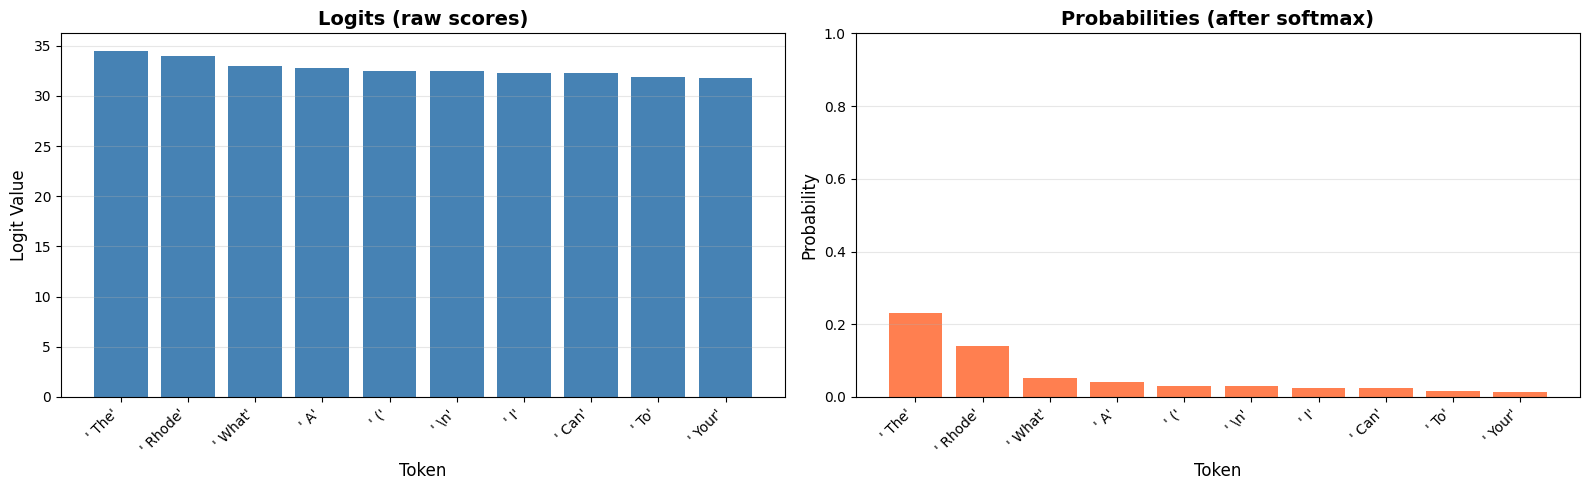

In [17]:
probs = F.softmax(last_token_logits, dim=-1)
top_10_probs = probs[top_10_indices]

print(f"Sum of probabilities for top-10 scoring tokens: {top_10_probs.sum().item():.6f}")
print(f"Sum of all probabilities: {probs.sum().item():.6f}")

for i, (token, logit, prob) in enumerate(zip(decoded_tokens, top_10_values, top_10_probs)):
    print(f"{i+1}. {token:20s} logit: {logit:7.2f}  ->  prob: {prob:7.5f} ({prob*100:5.2f}%)")

# Visualize logits vs probabilities
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

ax1.bar(range(10), top_10_values.cpu().numpy(), color='steelblue')
ax1.set_title("Logits (raw scores)", fontsize=14, fontweight='bold')
ax1.set_xlabel('Token', fontsize=12)
ax1.set_ylabel('Logit Value', fontsize=12)
ax1.set_xticks(range(10))
ax1.set_xticklabels(decoded_tokens, rotation=45, ha='right')
ax1.grid(axis='y', alpha=0.3)

ax2.bar(range(10), top_10_probs.cpu().numpy(), color='coral')
ax2.set_title("Probabilities (after softmax)", fontsize=14, fontweight='bold')
ax2.set_xlabel('Token', fontsize=12)
ax2.set_ylabel('Probability', fontsize=12)
ax2.set_xticks(range(10))
ax2.set_xticklabels(decoded_tokens, rotation=45, ha='right')
ax2.set_ylim(0, 1)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## Generation

Now that we understand how language models make predictions, let's see how we can use these predictions to generate new text. The process is conceptually simple but powerful:

1. **Start with a prompt** (like "What is the capital of Rhode Island?")
2. **Get predictions** for what token should come next
3. **Choose a token** from those predictions  
4. **Add it to our sequence** and repeat

This is called **autoregressive generation**, we generate one token at a time, using our previous generations to inform the next choice.

### Task: Generate a continuation

Implement autoregressive generation, generating a continuation to an initial prompt one token at a time.

Starting text: What is the capital of Rhode Island?


TypeError: 'NoneType' object is not subscriptable

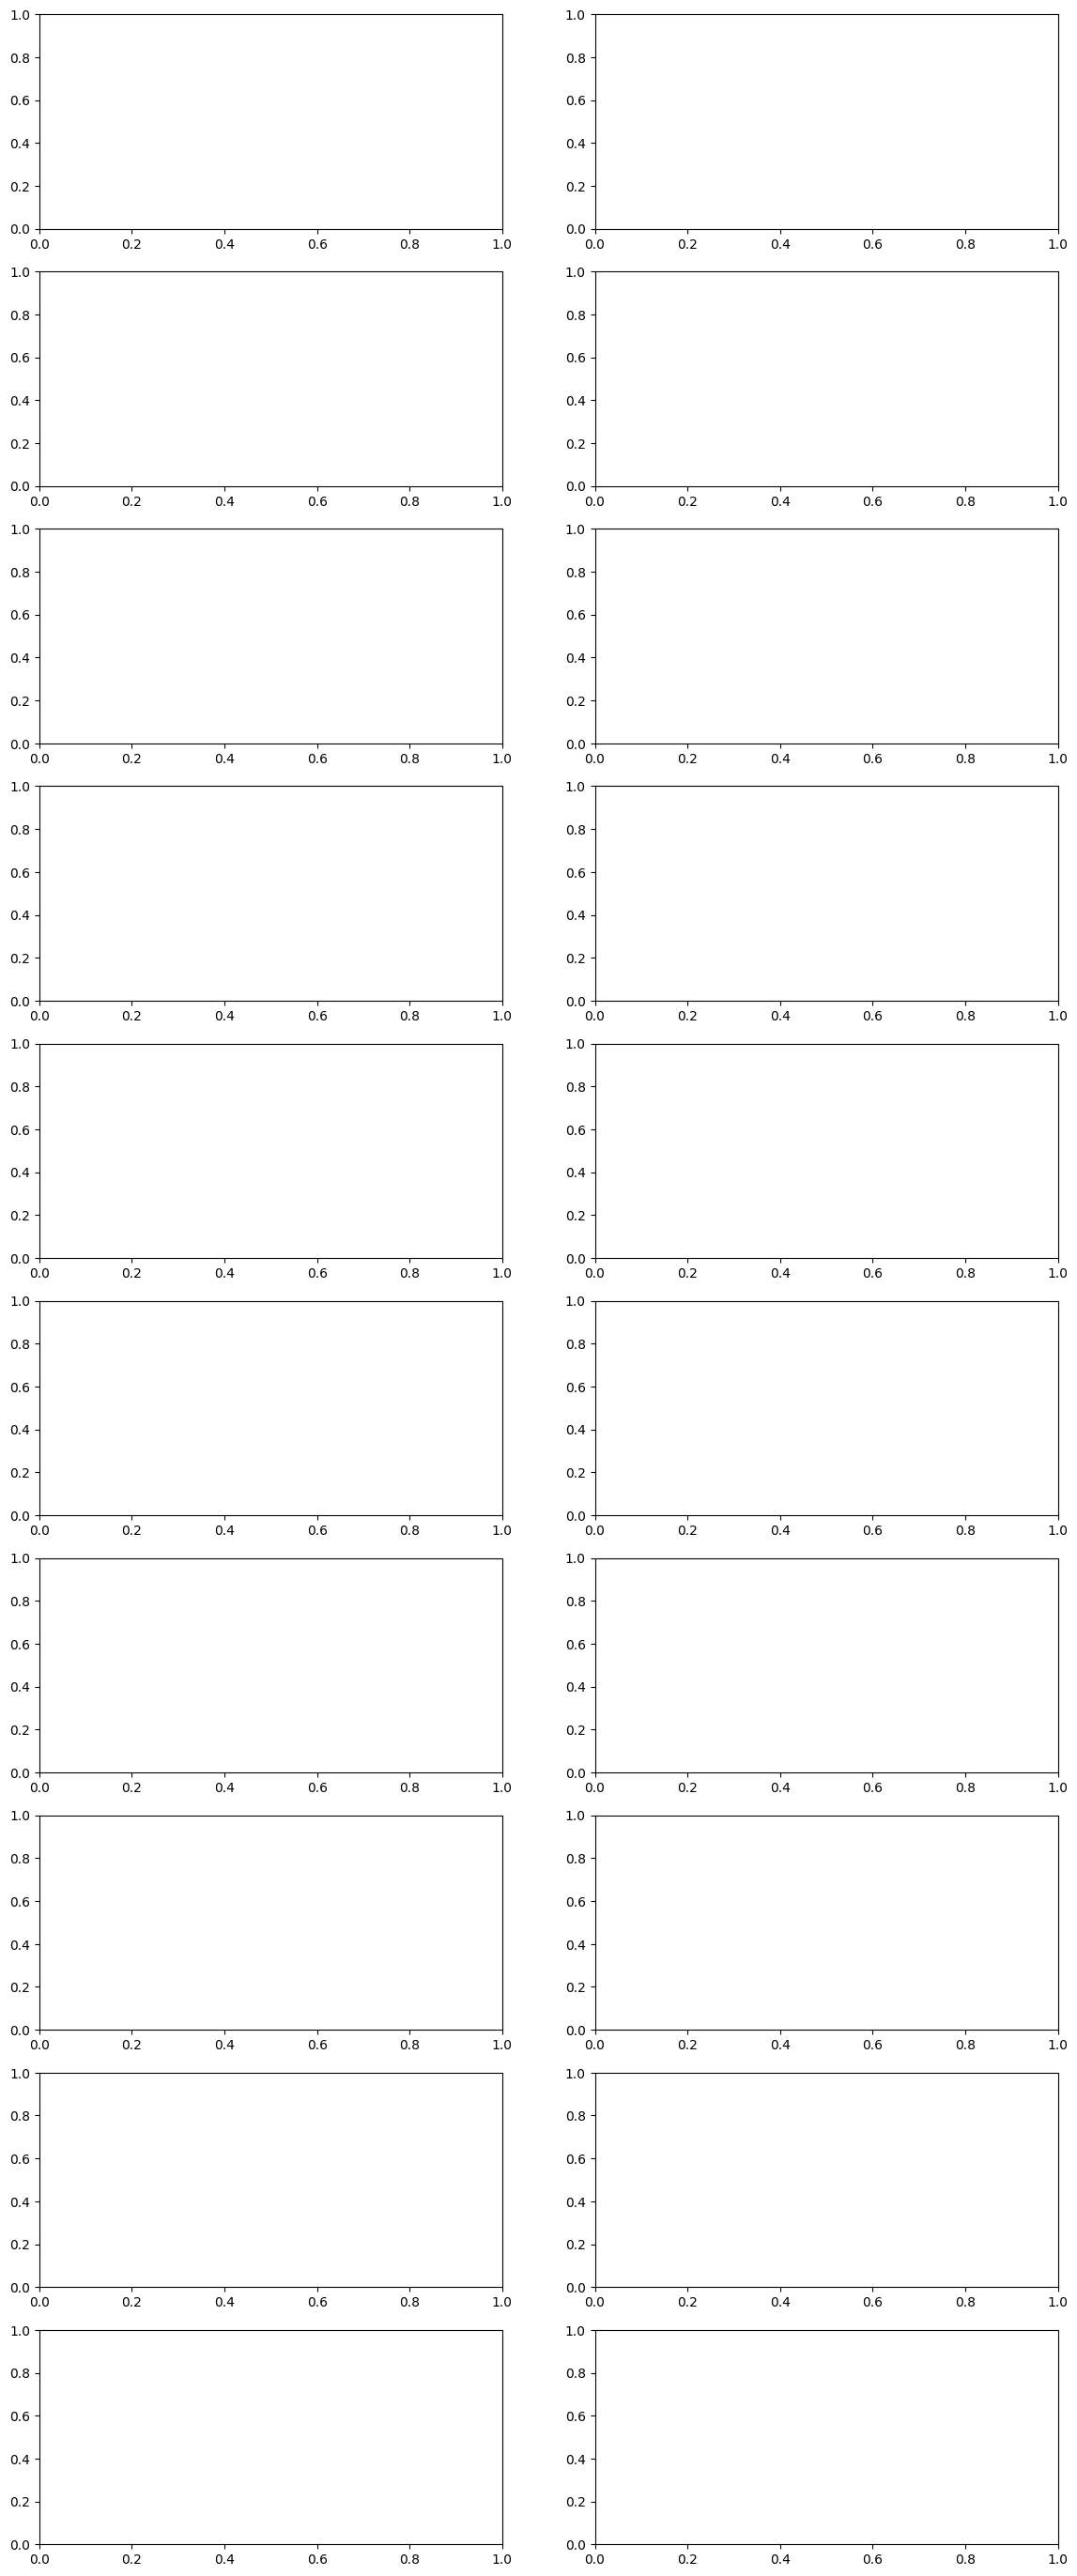

In [18]:
text = "What is the capital of Rhode Island?"
output = text
print(f"Starting text: {output}")

num_steps = 20
fig, axes = plt.subplots(10, 2, figsize=(14, 35))
axes = axes.flatten()

for i in range(num_steps):
    # TODO: Tokenize the output so far
    tokens = None

    with torch.no_grad():
        # TODO: Run the model on tokens
        predictions = None
        logits = None

    # Get top 10 predictions
    last_token_logits = logits[0, -1, :]
    top_10_values, top_10_indices = last_token_logits.sort(descending=True)
    top_10_indices = top_10_indices[:10]
    top_10_values = top_10_values[:10]

    # Decode tokens with special character handling for plots
    decoded_tokens = [tokenizer.decode(idx) for idx in top_10_indices]
    display_labels = [repr(t) if '\n' in t or '\t' in t or t == ' ' else t for t in decoded_tokens]

    # Plot
    axes[i].bar(range(len(decoded_tokens)), top_10_values.cpu().float().numpy(), color='steelblue')
    axes[i].set_xticks(range(len(decoded_tokens)))
    axes[i].set_xticklabels(display_labels, rotation=45, ha='right', fontsize=7)
    axes[i].set_ylabel('Logit', fontsize=9)
    axes[i].grid(axis='y', alpha=0.3)

    # Greedy decoding: pick token with highest logit
    # TODO: Select token with highest logit score
    next_token_id = None

    next_token = tokenizer.decode(next_token_id)

    # Title shows the current sequence
    title_text = output if len(output) < 60 else output[:57] + "..."
    axes[i].set_title(f"Step {i+1}: {title_text}", fontsize=8, fontweight='bold')

    # TODO: Append predicted next token to current output
    output = None
    print(f"Step {i+1}: Added {repr(next_token)}")

plt.suptitle('Greedy Generation: Top 10 Token Predictions at Each Step',
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print(f"Final output:\n{output}")

## Using Pipelines

Huggingface provides a convenient generation pipeline so that we don't have to write that autoregressive loop everytime.

In [ ]:
result = generator(
    "What is the capital of Rhode Island?",
    max_new_tokens=50,
    do_sample=False,
    pad_token_id=tokenizer.eos_token_id
)
print("Generated text:")
print(result[0]["generated_text"])

## Generation by Sampling

In the previous section, we used **greedy decoding** - always picking the token with the highest probability. While this is deterministic and often produces coherent text, it can be repetitive and lacks creativity. An alternative to greedy decoding is to sample the next token according to the predicted probabilities. There are a number of different sampling strategy commonly used by LLMs.

### Temperature Sampling

**Temperature** controls the "randomness" or "creativity" of generation by modifying the probability distribution before sampling:

- **Low temperature (0.1)**: Sharpens the distribution - high probability tokens become even more likely, making output more deterministic and conservative
- **High temperature (2.0)**: Flattens the distribution - makes lower probability tokens more likely, increasing randomness and creativity
- **Temperature = 1.0**: Uses the model's original probability distribution unchanged

**Mathematical intuition**: Temperature divides the logits before applying softmax. Lower values make the model more "confident" in its top choices, while higher values make it more "uncertain" and willing to explore alternatives.

In [ ]:
prompt = "The capital of Rhode Island is"
temperatures = [0.1, 0.5, 1.0, 1.5, 2.0]

print("Temperature controls randomness in generation:")
print("Low temperature (0.1): More deterministic, conservative")
print("High temperature (2.0): More random, creative\n")

for temp in temperatures:
    print(f"Temperature = {temp}:")
    result = generator(
        prompt,
        max_new_tokens=20,
        do_sample=True,
        temperature=temp,
        num_return_sequences=3,
        pad_token_id=tokenizer.eos_token_id
    )
    for j, output in enumerate(result):
        print(f"  {j+1}. {output['generated_text']}")
    print()

# Other Sampling Methods

Beyond temperature, there are other strategies to control which tokens get sampled:

**Top-k Sampling**: Only consider the k most likely tokens, ignore all others
- **Benefit**: Prevents sampling very unlikely tokens that might not make sense
- **Limitation**: Fixed k might be too restrictive for some contexts, too permissive for others

**Top-p (Nucleus) Sampling**: Sample from the smallest set of tokens whose probabilities sum to p
- **Benefit**: Adapts vocabulary size to context - uses more tokens when model is uncertain, fewer when confident
- **Common values**: p=0.9 or p=0.95 work well for most applications

Each of these are available in the Huggingface pipeline.

# Multi-Step conversations

Modern language models can handle multi-turn conversations by including the conversation history as context. At every generation step, the model takes in the entire history, with roles denoting who said what, and then produces new text in response.

**Common roles:**
- **system**: Instructions for how the model should behave (e.g., "You are a helpful assistant")
- **user**: Messages from the human
- **assistant**: Previous responses from the model

System prompts are particularly important for the behavior of LLMs. When LLM performance improves or otherwise changes **after** a model is released, it is typically because the system prompt has been adjusted. Since they are so important for a competitive model, they are typically kept secret... however, LLMs are particularly bad at keeping secrets and most major LLM system prompts are [available online](https://github.com/asgeirtj/system_prompts_leaks/tree/main).

In [ ]:
messages = [
    {"role": "system", "content": "You are a knowledgeable tour guide who provides interesting facts about places."},
    {"role": "user", "content": "What is the capital of Rhode Island?"},
    {"role": "assistant", "content": "The capital of Rhode Island is Providence."},
    {"role": "user", "content": "What does that city have to offer?"}
]

print("Conversation history:")
for msg in messages:
    print(f"{msg['role']}: {msg['content']}")
print("\nModel response:")

conversation_result = generator(messages, max_new_tokens=100)
print(conversation_result[0]["generated_text"])

# Task: Interactive Conversation

Write code to have an interactive conversation with Phi-4. You should use the python function `input` to get text from the keyboard. Your conversation should go for some `max_iterations`, which are the number of times each user (`user` and `assistant`) each participate.

In [ ]:
max_iterations = 3
max_tokens_per_iteration = 200

initial_prompt = "Can you quiz me on how Neural Networks work?"

messages = [
    {"role": "system", "content": "You are a helpful assistant that quizzes the user on how large language models (LLMs) work."},
    {"role": "user", "content": initial_prompt}
]

for i in range(max_iterations):
    print("Conversation history:")
    for msg in messages:
        print(f"{msg['role']}: {msg['content']}")
    print("\nModel response:")

    # TODO: Generate text from model using all messages
    conversation_result = pipe(
    messages,
    max_new_tokens=max_tokens_per_iteration
)
    # TODO: Get the most recent response from the model
    model_response = conversation_result[0]["generated_text"][-1]["content"]
    print(model_response)

    # Append the model's response to the conversation history
    messages.append({"role": "assistant", "content": model_response})

    # Get user input for the next turn
    user_input = input("Your response: ")

    # TODO: append your response to the
    messages.append({"role": "user", "content": user_input})

## README Questions

**Question 1: Tokenization Trade-offs**

Phi-4 (and most LLMs) use *sub-word* tokenization. There are other possible tokenization strategies, including:
1. Character-level tokenization (each token is a single character)
2. Word tokenization (each token is a word)
3. Bytle-level tokenization (each token is a numerical byte). This is a [recent trend](https://arxiv.org/pdf/2412.09871) in research to move LLMs away from tokenizers and have them generate byte code directly, rather than reason about individual tokens.

What advantages do you think sub-word tokenization have over the other options? What disadvantages does might it have?

**Question 2: An existential breakdown over seahorses**

Review [this](https://chatgpt.com/share/691164b3-ed30-800a-9999-a4a8cf01b5ac) conversation with ChatGPT (updated on 11/9/25)

A. Why is ChatGPT unable to correctly identify whether a seahorse emoji exists? (Hint: An emoji is represented as a token to a LLM)

B. Notice how ChatGPT repeatedly outputs 🐉 (dragon) while simultaneously "knowing" this is wrong. What does this suggest about the relationship between the model's token generation process and its semantic understanding of the tokens?

C. If we asked ChatGPT after this conversation "Why did you struggle to identify the seahorse emoji?", it would likely provide an accurate explanation about tokenization, Unicode representations, and how LLMs process special characters. However, it couldn't apply this knowledge during the actual generation. Why might this disconnect exist? How different (or not) is this from how humans reason?